##<b> The International Cricket Council (ICC) is the world governing body of cricket. It was founded as the Imperial Cricket Conference in 1909 by representatives from Australia, England and South Africa. It was renamed as the International Cricket Conference in 1965, and took up its current name in 1989. It organises world championship events such as Cricket World Cup, Women's Cricket World Cup, ICC T20 World Cup, ICC Women's T20 World Cup, ICC Champions Trophy and Under-19 Cricket World Cup.</b>

<br>

## <b> You recently got a lucky break in the field of Data Science. You got a job of Data Scientist at ICC. You are part of the Analytics Team which is involved in pre-match analyses, live-match analyses and post-match analyses. </b>

<br>

## <b>This data consists of 1417 T20 matches. Each row corresponds to a single T20 match. As a data scientist, you have to first explore the data and check its sanity. </b>

<br>

## <u><b>Further you are required to do some analyses :</b></u>
* ### Rename all the column names to their appropriate names, for example meta.created should be renamed as created_date
* ### Find out the top three venues which hosted the greatest number of matches.
* ### Find out the pair of cricket teams who played the most number of T20 matches against each other.
* ### Print the top five teams by their win percentages. Win percentage is defined as the number of matches won divided by the number of matches played and then multiplied by 100.
* ### Write a function to get the scorecard of each match. This function would take the innings value as argument and return two scorecard dataframes each for one team as shown below. So the first dataframe would contain the top 4 scorers of the team who batted first and the top 4 bowlers of the opponent team. And the second dataframe would contain the top 4 scorers of the team who batted second and the top 4 bowlers of the opponent team.




In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# <b><center> A sample scorecard </center></b>

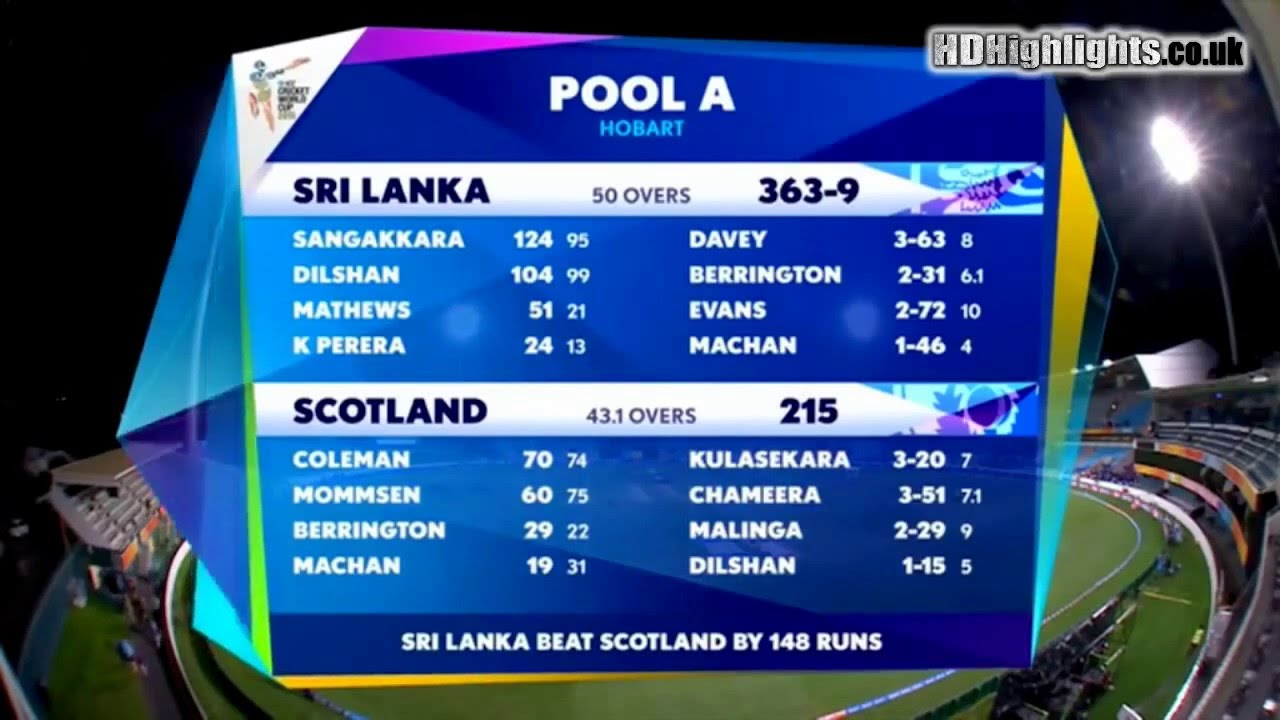

In [3]:
#Import package
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('/content/drive/MyDrive/International_T20_Data.csv')

In [5]:
df.head()

,innings,meta.data_version,meta.created,meta.revision,info.dates,info.gender,info.match_type,info.outcome.by.wickets,info.outcome.winner,info.overs,...,info.outcome.by.runs,info.match_type_number,info.neutral_venue,info.outcome.method,info.outcome.result,info.outcome.eliminator,info.supersubs.New Zealand,info.supersubs.South Africa,info.bowl_out,info.outcome.bowl_out
0,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-18,2,"[datetime.date(2017, 2, 17)]",male,T20,5.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-19,2,"[datetime.date(2017, 2, 19)]",male,T20,2.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-23,1,"[datetime.date(2017, 2, 22)]",male,T20,NaN,Australia,20,...,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[{'1st innings': {'team': 'Hong Kong', 'delive...",0.9,2016-09-12,1,"[datetime.date(2016, 9, 5)]",male,T20,NaN,Hong Kong,20,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[{'1st innings': {'team': 'Zimbabwe', 'deliver...",0.9,2016-06-19,1,"[datetime.date(2016, 6, 18)]",male,T20,NaN,Zimbabwe,20,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.columns

Index(['innings', 'meta.data_version', 'meta.created', 'meta.revision',
       'info.dates', 'info.gender', 'info.match_type',
       'info.outcome.by.wickets', 'info.outcome.winner', 'info.overs',
       'info.player_of_match', 'info.teams', 'info.toss.decision',
       'info.toss.winner', 'info.umpires', 'info.venue', 'info.city',
       'info.outcome.by.runs', 'info.match_type_number', 'info.neutral_venue',
       'info.outcome.method', 'info.outcome.result', 'info.outcome.eliminator',
       'info.supersubs.New Zealand', 'info.supersubs.South Africa',
       'info.bowl_out', 'info.outcome.bowl_out'],
      dtype='object')

In [7]:
df = df.rename(columns={
    'meta.created': 'created_date',
    'meta.revision': 'revision',
    'info.city': 'city',
    'info.venue': 'venue',
    'info.dates': 'match_date',
    'info.outcome.winner': 'winner',
    'info.outcome.by.runs': 'win_by_runs',
    'info.outcome.by.wickets': 'win_by_wickets',
    'info.toss.winner': 'toss_winner',
    'info.toss.decision': 'toss_decision'
})

In [8]:
df.columns

Index(['innings', 'meta.data_version', 'created_date', 'revision',
       'match_date', 'info.gender', 'info.match_type', 'win_by_wickets',
       'winner', 'info.overs', 'info.player_of_match', 'info.teams',
       'toss_decision', 'toss_winner', 'info.umpires', 'venue', 'city',
       'win_by_runs', 'info.match_type_number', 'info.neutral_venue',
       'info.outcome.method', 'info.outcome.result', 'info.outcome.eliminator',
       'info.supersubs.New Zealand', 'info.supersubs.South Africa',
       'info.bowl_out', 'info.outcome.bowl_out'],
      dtype='object')

In [9]:
df.head()

,innings,meta.data_version,created_date,revision,match_date,info.gender,info.match_type,win_by_wickets,winner,info.overs,...,win_by_runs,info.match_type_number,info.neutral_venue,info.outcome.method,info.outcome.result,info.outcome.eliminator,info.supersubs.New Zealand,info.supersubs.South Africa,info.bowl_out,info.outcome.bowl_out
0,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-18,2,"[datetime.date(2017, 2, 17)]",male,T20,5.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-19,2,"[datetime.date(2017, 2, 19)]",male,T20,2.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-23,1,"[datetime.date(2017, 2, 22)]",male,T20,NaN,Australia,20,...,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[{'1st innings': {'team': 'Hong Kong', 'delive...",0.9,2016-09-12,1,"[datetime.date(2016, 9, 5)]",male,T20,NaN,Hong Kong,20,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[{'1st innings': {'team': 'Zimbabwe', 'deliver...",0.9,2016-06-19,1,"[datetime.date(2016, 6, 18)]",male,T20,NaN,Zimbabwe,20,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
top_venues = df['venue'].value_counts().head(3)
print(top_venues)

venue
Dubai International Cricket Stadium    62
Sheikh Zayed Stadium                   41
Shere Bangla National Stadium          39
Name: count, dtype: int64


In [11]:
df['team_pair'] = df['info.teams'].apply(lambda x: tuple(sorted(eval(x))))

most_matches = df['team_pair'].value_counts().head(1)

print(most_matches)

team_pair
(Australia, England)    45
Name: count, dtype: int64


In [12]:
import ast

df['info.teams'] = df['info.teams'].apply(ast.literal_eval)

In [13]:
matches_played = df['info.teams'].explode().value_counts()

In [14]:
matches_won = df['winner'].value_counts()

In [15]:
win_percentage = (matches_won / matches_played) * 100
win_percentage = win_percentage.fillna(0)

In [16]:
top5 = win_percentage.sort_values(ascending=False).head(5)
print(top5)

Belgium        100.000000
Spain           83.333333
Germany         76.470588
Namibia         73.529412
Afghanistan     68.000000
Name: count, dtype: float64


In [17]:
print(df['innings'].iloc[0])

[{'1st innings': {'team': 'Australia', 'deliveries': [{0.1: {'batsman': 'AJ Finch', 'bowler': 'SL Malinga', 'non_striker': 'M Klinger', 'runs': {'batsman': 0, 'extras': 0, 'total': 0}}}, {0.2: {'batsman': 'AJ Finch', 'bowler': 'SL Malinga', 'non_striker': 'M Klinger', 'runs': {'batsman': 0, 'extras': 0, 'total': 0}}}, {0.3: {'batsman': 'AJ Finch', 'bowler': 'SL Malinga', 'non_striker': 'M Klinger', 'runs': {'batsman': 1, 'extras': 0, 'total': 1}}}, {0.4: {'batsman': 'M Klinger', 'bowler': 'SL Malinga', 'non_striker': 'AJ Finch', 'runs': {'batsman': 2, 'extras': 0, 'total': 2}}}, {0.5: {'batsman': 'M Klinger', 'bowler': 'SL Malinga', 'non_striker': 'AJ Finch', 'runs': {'batsman': 0, 'extras': 0, 'total': 0}}}, {0.6: {'batsman': 'M Klinger', 'bowler': 'SL Malinga', 'non_striker': 'AJ Finch', 'runs': {'batsman': 3, 'extras': 0, 'total': 3}}}, {1.1: {'batsman': 'M Klinger', 'bowler': 'KMDN Kulasekara', 'non_striker': 'AJ Finch', 'runs': {'batsman': 0, 'extras': 0, 'total': 0}}}, {1.2: {'ba

In [18]:
import ast

df['innings'] = df['innings'].apply(ast.literal_eval)

In [19]:
def extract_innings(df):

    rows = []

    for match in df['innings'].dropna():

        for inning in match:

            inning_name = list(inning.keys())[0]
            deliveries = inning[inning_name]['deliveries']

            inning_no = 1 if '1st' in inning_name else 2

            for delivery in deliveries:

                ball = list(delivery.keys())[0]
                data = delivery[ball]

                batsman = data.get('batsman')
                bowler = data.get('bowler')
                runs = data.get('runs', {}).get('batsman', 0)

                wicket = 1 if 'wicket' in data else 0

                rows.append({
                    'batsman': batsman,
                    'bowler': bowler,
                    'runs': runs,
                    'wicket': wicket,
                    'innings': inning_no
                })

    return pd.DataFrame(rows)

In [20]:
ball_df = extract_innings(df)
ball_df.head()
ball_df.shape

(324536, 5)

In [21]:
def get_scorecard(ball_df):

    first = ball_df[ball_df['innings'] == 1]
    second = ball_df[ball_df['innings'] == 2]

    top_bat1 = first.groupby('batsman')['runs'].sum().sort_values(ascending=False).head(4).reset_index()
    top_bowl1 = first.groupby('bowler')['wicket'].sum().sort_values(ascending=False).head(4).reset_index()

    score1 = pd.concat([top_bat1, top_bowl1], axis=1)

    top_bat2 = second.groupby('batsman')['runs'].sum().sort_values(ascending=False).head(4).reset_index()
    top_bowl2 = second.groupby('bowler')['wicket'].sum().sort_values(ascending=False).head(4).reset_index()

    score2 = pd.concat([top_bat2, top_bowl2], axis=1)

    return score1, score2

In [22]:
score1, score2 = get_scorecard(ball_df)

print("First Innings")
print(score1)

print("\nSecond Innings")
print(score2)

First Innings
           batsman  runs       bowler  wicket
0        RG Sharma  1644   SL Malinga      55
1       MJ Guptill  1425     Umar Gul      53
2  Mohammad Hafeez  1285  A Shrubsole      53
3     Shoaib Malik  1266   TG Southee      52

Second Innings
      batsman  runs         bowler  wicket
0     V Kohli  1567     SL Malinga      69
1   DA Warner  1307  Shahid Afridi      62
2  EJG Morgan  1210    Rashid Khan      57
3   RG Sharma  1144    Saeed Ajmal      51


In [24]:
#NumPy Operations
runs = np.array(df['win_by_runs'])
np.mean(runs)
np.median(runs)
np.std(runs)
np.var(runs)
np.max(runs)
np.min(runs)
np.random.choice(runs,10)

array([nan, 16., 28., nan, 39., nan, nan, 27., nan, 90.])

In [25]:
#pivot table
pd.pivot_table(df,
               values='win_by_runs',
               index='city',
               aggfunc=np.mean)

/tmp/ipykernel_435/1998697014.py:2: FutureWarning: The provided callable <function mean at 0x7c37b0de9a80> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pd.pivot_table(df,


,win_by_runs
city,
Abu Dhabi,26.318182
Adelaide,134.000000
Ahmedabad,11.000000
Al Amarat,46.666667
Almeria,58.000000
...,...
Utrecht,26.000000
Victoria,8.000000
Walferdange,57.666667


In [26]:
#correlation analysis
df.corr(numeric_only=True)

,meta.data_version,revision,win_by_wickets,info.overs,win_by_runs,info.match_type_number,info.neutral_venue
meta.data_version,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revision,NaN,1.000000,-0.024809,-0.029680,-0.123323,-0.023927,NaN
win_by_wickets,NaN,-0.024809,1.000000,0.010344,NaN,-0.035172,NaN
info.overs,NaN,-0.029680,0.010344,1.000000,0.021201,0.093451,NaN
win_by_runs,NaN,-0.123323,NaN,0.021201,1.000000,-0.094147,NaN
info.match_type_number,NaN,-0.023927,-0.035172,0.093451,-0.094147,1.000000,NaN
info.neutral_venue,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

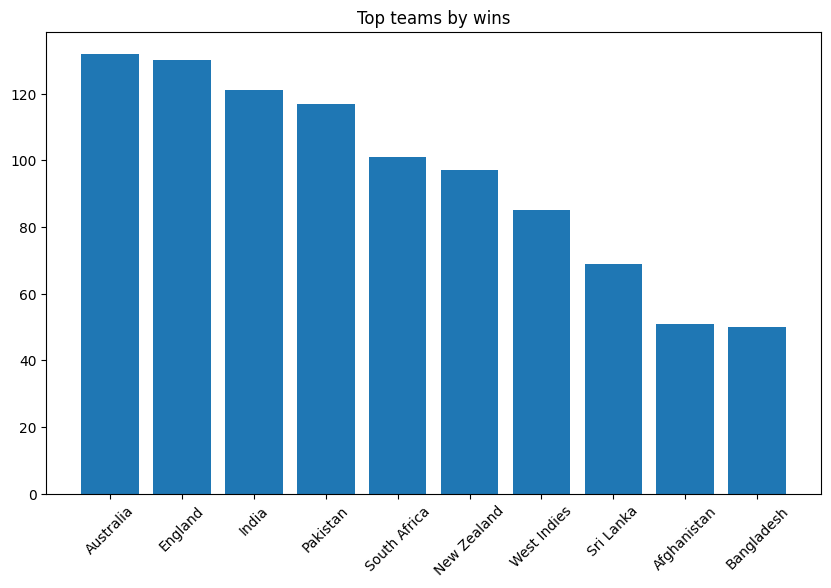

In [28]:
#Matplotlib Visualization
teams = df['winner'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(teams.index, teams.values)
plt.xticks(rotation=45)
plt.title("Top teams by wins")
plt.show()

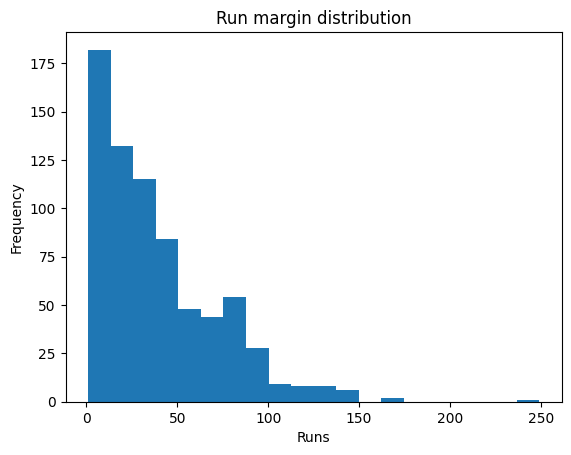

In [29]:
#histogram
plt.hist(df['win_by_runs'], bins=20)
plt.title("Run margin distribution")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

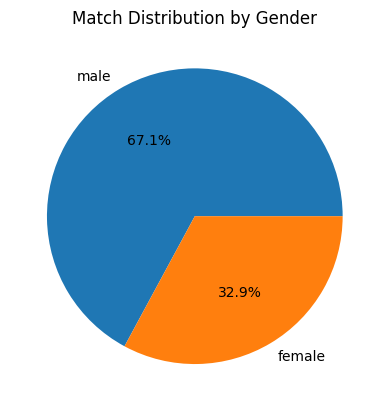

In [30]:
#pie chart
gender = df['info.gender'].value_counts()

plt.pie(gender.values, labels=gender.index, autopct='%1.1f%%')
plt.title("Match Distribution by Gender")
plt.show()

In [31]:
#Seaborn Visualization

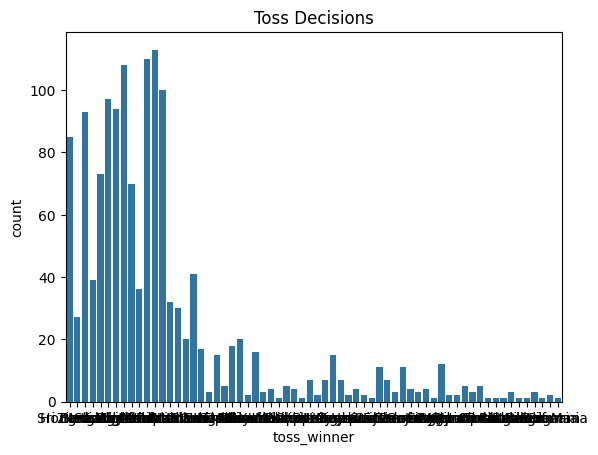

In [32]:
#count plot
sns.countplot(x='toss_winner', data=df)
plt.title("Toss Decisions")
plt.show()

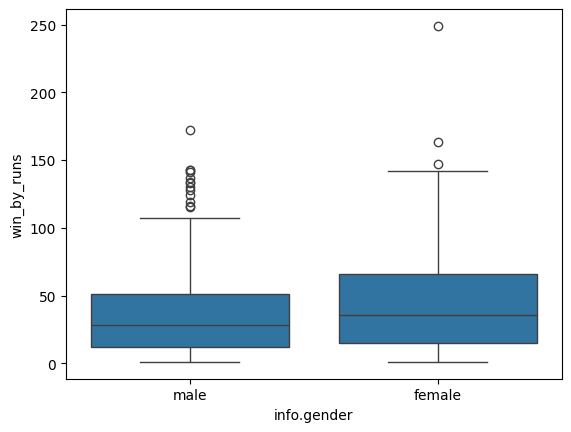

In [33]:
#box plot
sns.boxplot(x='info.gender', y='win_by_runs', data=df)
plt.show()

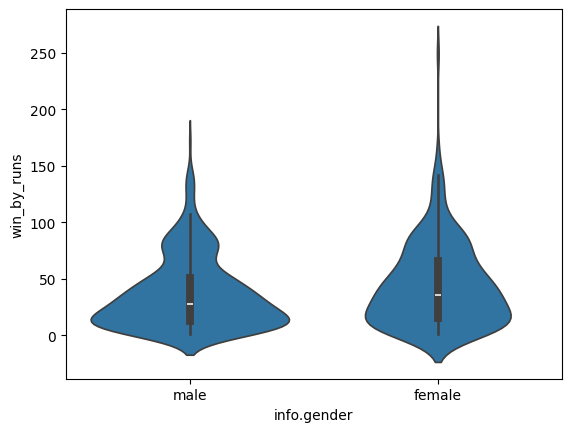

In [34]:
#violin plot
sns.violinplot(x='info.gender', y='win_by_runs', data=df)
plt.show()

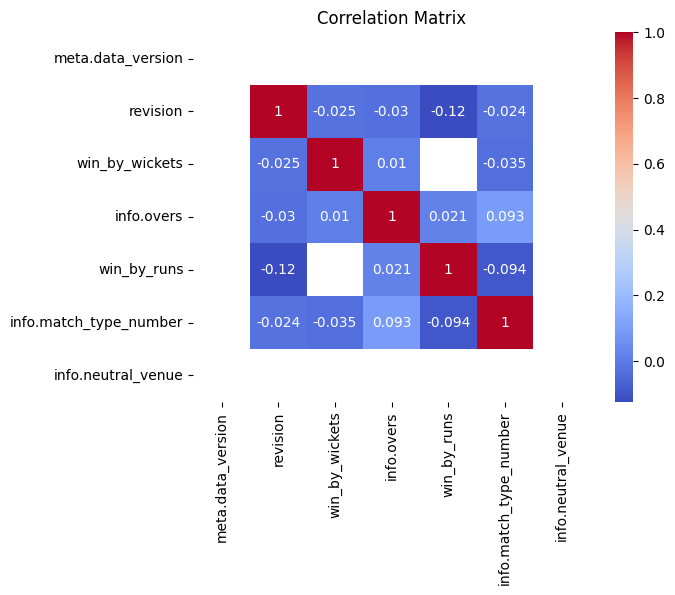

In [36]:
#heatmap
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [37]:
#Advanced Analysis

#top venues
df['venue'].value_counts().head(10)

,count
venue,
Dubai International Cricket Stadium,62
Sheikh Zayed Stadium,41
Shere Bangla National Stadium,39
R Premadasa Stadium,35
Kinrara Academy Oval,32
County Ground,27
Sylhet Stadium,26
New Wanderers Stadium,25
Harare Sports Club,24
